In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor


In [2]:
df = pd.read_csv('../data/raw/student_habits_performance.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [3]:
empyty_df = df[df['parental_education_level'].isnull()]
empyty_df

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
10,S1010,19,Female,4.6,3.7,0.8,No,77.6,5.8,Fair,1,NaN,Good,3,No,63.3
33,S1033,18,Female,4.0,0.9,1.1,No,99.5,5.8,Poor,2,NaN,Average,5,No,70.7
47,S1047,23,Female,2.5,2.9,2.7,No,83.5,7.0,Good,4,NaN,Good,8,Yes,59.7
74,S1074,21,Female,2.3,1.0,0.4,No,100.0,6.4,Fair,6,NaN,Good,1,No,66.9
93,S1093,22,Male,4.1,2.5,3.0,No,85.1,5.8,Good,4,NaN,Good,5,No,70.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
921,S1921,23,Female,4.4,2.7,1.0,No,79.8,6.1,Fair,6,NaN,Average,3,No,85.4
925,S1925,19,Other,1.7,2.9,1.6,Yes,97.3,8.7,Good,1,NaN,Good,7,No,53.6
939,S1939,18,Female,4.7,3.2,1.9,No,75.2,5.4,Good,3,NaN,Good,6,No,71.0
945,S1945,23,Male,6.0,2.9,2.1,Yes,98.9,6.4,Poor,0,NaN,Average,7,No,100.0


In [4]:
df['parental_education_level'] = df['parental_education_level'].fillna(df['parental_education_level'].mode()[0])

In [5]:
empyty_df.index

Index([ 10,  33,  47,  74,  93, 100, 102, 107, 115, 116, 117, 143, 145, 149,
       153, 178, 180, 202, 214, 261, 277, 282, 285, 290, 303, 307, 320, 331,
       334, 365, 376, 391, 401, 403, 415, 418, 421, 437, 442, 465, 480, 482,
       486, 497, 502, 505, 507, 512, 526, 531, 539, 554, 555, 562, 569, 602,
       603, 620, 637, 645, 647, 662, 666, 677, 680, 681, 682, 689, 708, 728,
       740, 760, 766, 782, 785, 795, 802, 824, 829, 836, 872, 887, 899, 910,
       911, 920, 921, 925, 939, 945, 967],
      dtype='int64')

In [6]:
df.loc[empyty_df.index]

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
10,S1010,19,Female,4.6,3.7,0.8,No,77.6,5.8,Fair,1,High School,Good,3,No,63.3
33,S1033,18,Female,4.0,0.9,1.1,No,99.5,5.8,Poor,2,High School,Average,5,No,70.7
47,S1047,23,Female,2.5,2.9,2.7,No,83.5,7.0,Good,4,High School,Good,8,Yes,59.7
74,S1074,21,Female,2.3,1.0,0.4,No,100.0,6.4,Fair,6,High School,Good,1,No,66.9
93,S1093,22,Male,4.1,2.5,3.0,No,85.1,5.8,Good,4,High School,Good,5,No,70.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
921,S1921,23,Female,4.4,2.7,1.0,No,79.8,6.1,Fair,6,High School,Average,3,No,85.4
925,S1925,19,Other,1.7,2.9,1.6,Yes,97.3,8.7,Good,1,High School,Good,7,No,53.6
939,S1939,18,Female,4.7,3.2,1.9,No,75.2,5.4,Good,3,High School,Good,6,No,71.0
945,S1945,23,Male,6.0,2.9,2.1,Yes,98.9,6.4,Poor,0,High School,Average,7,No,100.0


In [7]:
cat_cols = df.describe(include='object').columns.tolist()[1:]
num_cols = df.select_dtypes(exclude="object").columns.to_list()

for col in cat_cols:
    col_value = df[col].value_counts().reset_index()
    print(f"Value count for {col}:\n{col_value}\n")

Value count for gender:
   gender  count
0  Female    481
1    Male    477
2   Other     42

Value count for part_time_job:
  part_time_job  count
0            No    785
1           Yes    215

Value count for diet_quality:
  diet_quality  count
0         Fair    437
1         Good    378
2         Poor    185

Value count for parental_education_level:
  parental_education_level  count
0              High School    483
1                 Bachelor    350
2                   Master    167

Value count for internet_quality:
  internet_quality  count
0             Good    447
1          Average    391
2             Poor    162

Value count for extracurricular_participation:
  extracurricular_participation  count
0                            No    682
1                           Yes    318



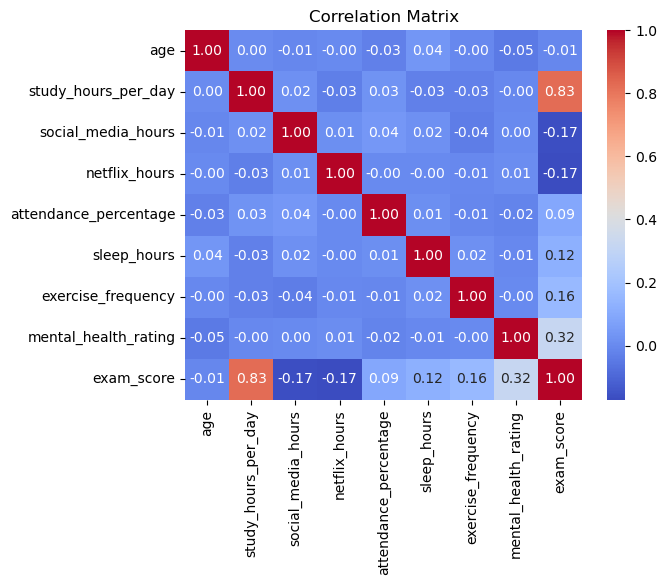

In [8]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.savefig("../reports/v2_figs/correlation_matrix.png")
plt.show()

In [9]:
feature_df = df.drop('student_id', axis=1)
feature_df

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


Label Encoding for Ordinal data
small -> 0
medium -> 1
large -> 2

One Hot Encoding for Nominal Data
Red -> 0, 0
Blue -> 0, 1
Green -> 1, 0

In [10]:
diet_quality = {'Poor': 0, 'Fair': 1, 'Good': 2}
parental_education_level = {'High School' : 0, 'Bachelor' : 1, 'Master' : 2}
internet_quality  = {'Poor' : 0, 'Average' : 1, 'Good' : 2}

In [11]:
feature_df['dq_e'] =feature_df['diet_quality'].map(diet_quality)
feature_df['pel_e'] =feature_df['parental_education_level'].map(parental_education_level)
feature_df['iq_e'] =feature_df['internet_quality'].map(internet_quality)

In [12]:
feature_df

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,dq_e,pel_e,iq_e
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2,1,2,1
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0,2,0,1
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3,0,0,0
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8,0,2,2
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1,1,0,2
996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9,0,0,1
997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4,2,1,2
998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7,1,1,1


In [13]:
dummies_df = pd.get_dummies(df[['gender', 'part_time_job', 'extracurricular_participation']], drop_first=True)
dummies_df

,gender_Male,gender_Other,part_time_job_Yes,extracurricular_participation_Yes
0,False,False,False,True
1,False,False,False,False
2,True,False,False,False
3,False,False,False,True
4,False,False,False,False
...,...,...,...,...
995,False,False,False,True
996,False,False,True,True
997,True,False,False,True
998,True,False,True,False


In [14]:
new_features_df = pd.concat([feature_df, dummies_df], axis=1)
new_features_df

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,...,mental_health_rating,extracurricular_participation,exam_score,dq_e,pel_e,iq_e,gender_Male,gender_Other,part_time_job_Yes,extracurricular_participation_Yes
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,...,8,Yes,56.2,1,2,1,False,False,False,True
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,...,8,No,100.0,2,0,1,False,False,False,False
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,...,1,No,34.3,0,0,0,True,False,False,False
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,...,1,Yes,26.8,0,2,2,False,False,False,True
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,...,1,No,66.4,1,2,2,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,...,6,Yes,76.1,1,0,2,False,False,False,True
996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,...,6,Yes,65.9,0,0,1,False,False,True,True
997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,...,9,Yes,64.4,2,1,2,True,False,False,True
998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,...,1,No,69.7,1,1,1,True,False,True,False


In [15]:
new_features_df.drop(cat_cols, axis=1, inplace=True)
new_features_df

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score,dq_e,pel_e,iq_e,gender_Male,gender_Other,part_time_job_Yes,extracurricular_participation_Yes
0,23,0.0,1.2,1.1,85.0,8.0,6,8,56.2,1,2,1,False,False,False,True
1,20,6.9,2.8,2.3,97.3,4.6,6,8,100.0,2,0,1,False,False,False,False
2,21,1.4,3.1,1.3,94.8,8.0,1,1,34.3,0,0,0,True,False,False,False
3,23,1.0,3.9,1.0,71.0,9.2,4,1,26.8,0,2,2,False,False,False,True
4,19,5.0,4.4,0.5,90.9,4.9,3,1,66.4,1,2,2,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,21,2.6,0.5,1.6,77.0,7.5,2,6,76.1,1,0,2,False,False,False,True
996,17,2.9,1.0,2.4,86.0,6.8,1,6,65.9,0,0,1,False,False,True,True
997,20,3.0,2.6,1.3,61.9,6.5,5,9,64.4,2,1,2,True,False,False,True
998,24,5.4,4.1,1.1,100.0,7.6,0,1,69.7,1,1,1,True,False,True,False


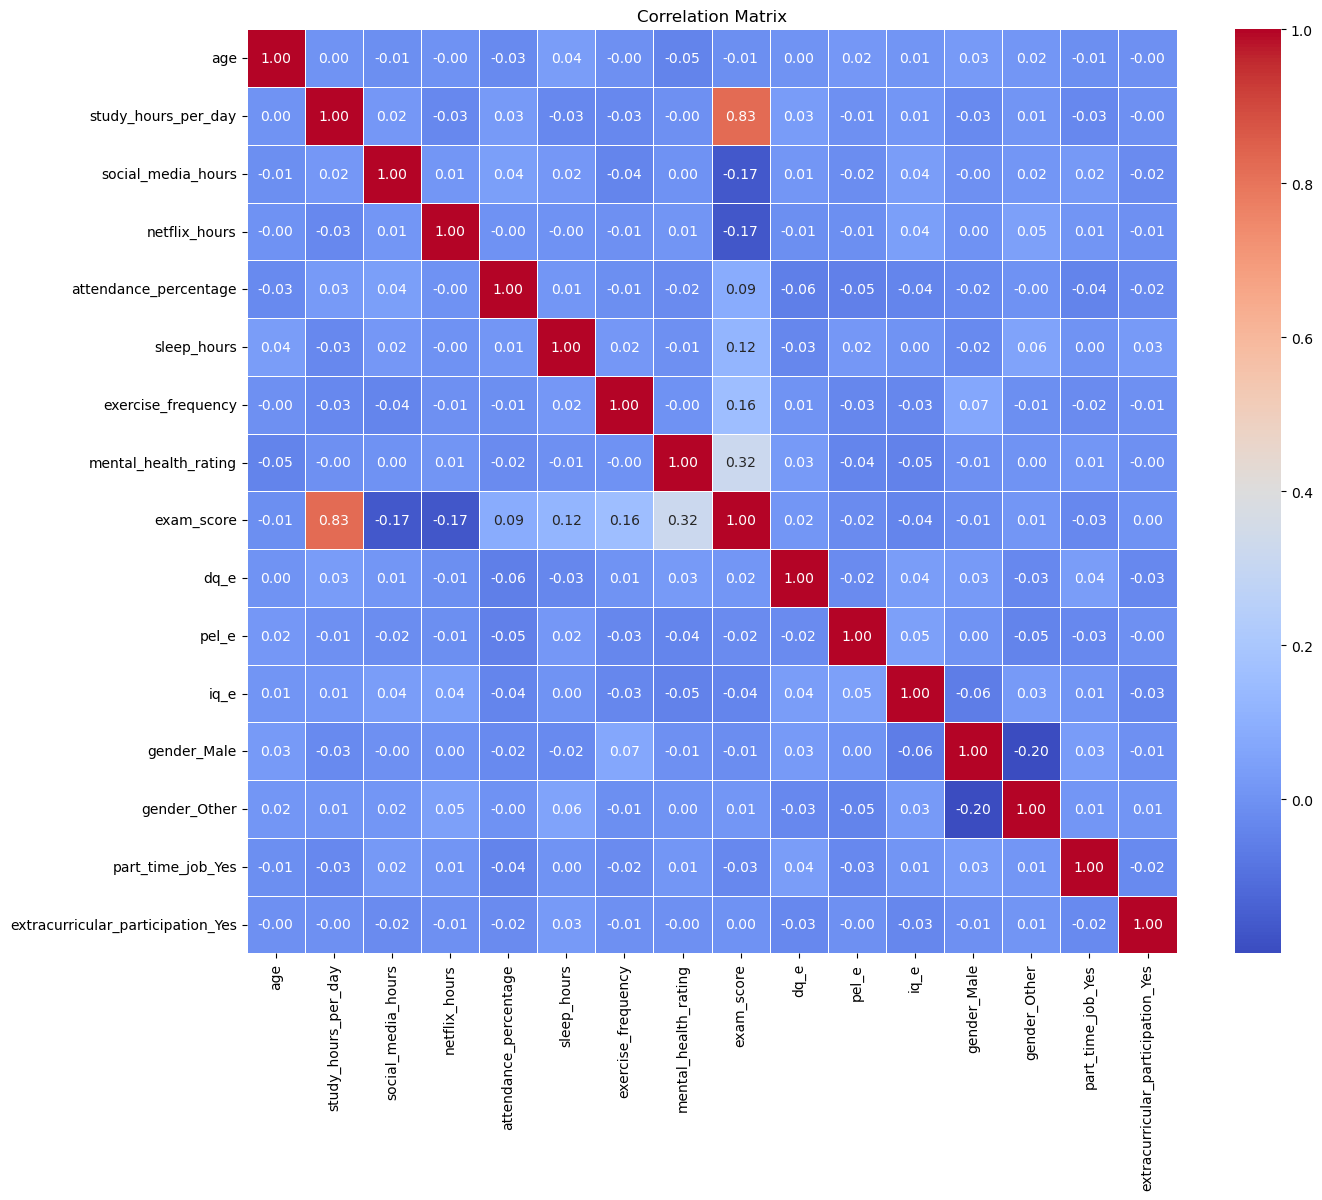

In [16]:
plt.figure(figsize=(15, 12))
sns.heatmap(new_features_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 10}, linewidths=0.5)
plt.title("Correlation Matrix")
plt.savefig("../reports/v2_figs/new_features_correlation_matrix.png")
plt.show()

In [17]:
new_features_df.columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score', 'dq_e', 'pel_e', 'iq_e',
       'gender_Male', 'gender_Other', 'part_time_job_Yes',
       'extracurricular_participation_Yes'],
      dtype='object')

In [18]:
features = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'dq_e', 'pel_e', 'iq_e',
       'gender_Male', 'gender_Other', 'part_time_job_Yes',
       'extracurricular_participation_Yes']

target = 'exam_score'

df_model = new_features_df[features + [target]].copy()

X = df_model[features]
y = df_model[target]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(y_train)
len(y_test)

200

In [20]:
# models

models = {
    "LinearRegression": {"model": LinearRegression(), "params": {}},
    "DecisionTree": {
        "model": DecisionTreeRegressor(),
        "params": {"max_depth": [3, 5, 10], "min_samples_split": [2, 5]},
    },
    "RandomForest": {
        "model": RandomForestRegressor(),
        "params": {"n_estimators": [50, 100], "max_depth": [5, 10]},
    },
}

best_models = []

for name, config in models.items():
    print(f"Training {name}")

    grid = GridSearchCV(
        config["model"], config["params"], cv=5, scoring="neg_mean_squared_error"
    )
    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    best_models.append(
        {"model": name, "best_params": grid.best_params_, "rmse": rmse, "r2": r2}
    )

results_df = pd.DataFrame(best_models)

Training LinearRegression
Training DecisionTree
Training RandomForest


In [21]:
results_df

,model,best_params,rmse,r2
0,LinearRegression,{},5.093314,0.898834
1,DecisionTree,"{'max_depth': 5, 'min_samples_split': 2}",8.904073,0.690821
2,RandomForest,"{'max_depth': 10, 'n_estimators': 100}",6.220662,0.849094


In [22]:
best_row = results_df.sort_values(by="rmse").iloc[0]

best_model_name = best_row["model"]

best_model_config = models[best_model_name]

# final_model = best_model_config["model"].set_params(**best_row['best_params'])
final_model = best_model_config["model"]

final_model.fit(X, y)

joblib.dump(final_model, "../models/model_v2/best_model_v2.pkl")

['../models/model_v2/best_model_v2.pkl']